In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [71]:
df = pd.read_csv('../data/online_retail_II.csv', encoding='latin-1')
df.shape

(1067371, 8)

In [72]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [74]:
# Facturas canceladas (empiezan con 'C')
canceladas = df['Invoice'].str.startswith('C').sum()

# Cantidades negativas o cero
qty_neg = (df['Quantity'] <= 0).sum()

# Precios negativos o cero
price_neg = (df['Price'] <= 0).sum()

# Filas duplicadas exactas
duplicados = df.duplicated().sum()

print(f'Facturas canceladas: {canceladas}')
print(f'Cantidad <= 0: {qty_neg}')
print(f'Precio <= 0: {price_neg}')
print(f'Duplicados exactos: {duplicados}')

Facturas canceladas: 19494
Cantidad <= 0: 22950
Precio <= 0: 6207
Duplicados exactos: 34335


In [75]:
df_clean = df.copy()

# 1. Eliminar duplicados exactos
df_clean = df_clean.drop_duplicates()

# 2. Excluir registros sin cliente
df_clean = df_clean.dropna(subset=['Customer ID'])

# 3. Excluir cancelaciones, cantidades y precios inválidos
df_clean = df_clean[~df_clean['Invoice'].str.startswith('C')]
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['Price'] > 0]

# 4. Corregir tipos de dato
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)

# 5. Crear columna de monto por línea (la vamos a usar en RFM)
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['Price']

print(f'Filas originales: {len(df)}')
print(f'Filas limpias: {len(df_clean)}')
print(f'Filas excluidas: {len(df) - len(df_clean)} ({(len(df)-len(df_clean))/len(df)*100:.1f}%)')

Filas originales: 1067371
Filas limpias: 779425
Filas excluidas: 287946 (27.0%)


In [76]:
print(f"Rango de fechas: {df_clean['InvoiceDate'].min()} a {df_clean['InvoiceDate'].max()}")
print(f"Clientes únicos: {df_clean['Customer ID'].nunique()}")
print(f"Facturas únicas: {df_clean['Invoice'].nunique()}")
print(f"Países: {df_clean['Country'].nunique()}")
print(f"Facturación total: £{df_clean['TotalAmount'].sum():,.0f}")

Rango de fechas: 2009-12-01 07:45:00 a 2011-12-09 12:50:00
Clientes únicos: 5878
Facturas únicas: 36969
Países: 41
Facturación total: £17,374,804


In [77]:
import sqlite3

conn = sqlite3.connect('../retail.db')
df_clean.to_sql('ventas', conn, if_exists='replace', index=False)

# Verificación: contar filas desde SQL
pd.read_sql('SELECT COUNT(*) AS total FROM ventas', conn)

,total
0,779425


In [78]:
query_rfm = """
WITH compras_por_cliente AS (
    SELECT
        "Customer ID" AS customer_id,
        MAX(InvoiceDate) AS ultima_compra,
        COUNT(DISTINCT Invoice) AS frecuencia,
        SUM(TotalAmount) AS monto_total
    FROM ventas
    GROUP BY "Customer ID"
)
SELECT
    customer_id,
    CAST(JULIANDAY('2011-12-10') - JULIANDAY(ultima_compra) AS INTEGER) AS recencia_dias,
    frecuencia,
    ROUND(monto_total, 2) AS monto
FROM compras_por_cliente
ORDER BY monto DESC
"""

rfm = pd.read_sql(query_rfm, conn)
print(rfm.shape)
rfm.head(10)

(5878, 4)


,customer_id,recencia_dias,frecuencia,monto
0,18102,0,145,580987.04
1,14646,1,151,528602.52
2,14156,9,156,313437.62
3,14911,1,398,291420.81
4,17450,8,51,244784.25
5,13694,3,143,195640.69
6,17511,2,60,172132.87
7,16446,0,2,168472.50
8,16684,4,55,147142.77
9,12415,24,28,144458.37


In [79]:
query_scores = """
WITH compras_por_cliente AS (
    SELECT
        "Customer ID" AS customer_id,
        MAX(InvoiceDate) AS ultima_compra,
        COUNT(DISTINCT Invoice) AS frecuencia,
        SUM(TotalAmount) AS monto_total
    FROM ventas
    GROUP BY "Customer ID"
),
rfm_base AS (
    SELECT
        customer_id,
        CAST(JULIANDAY('2011-12-10') - JULIANDAY(ultima_compra) AS INTEGER) AS recencia_dias,
        frecuencia,
        monto_total
    FROM compras_por_cliente
)
SELECT
    customer_id,
    recencia_dias,
    frecuencia,
    ROUND(monto_total, 2) AS monto,
    NTILE(5) OVER (ORDER BY recencia_dias DESC) AS r_score,
    NTILE(5) OVER (ORDER BY frecuencia ASC) AS f_score,
    NTILE(5) OVER (ORDER BY monto_total ASC) AS m_score
FROM rfm_base
"""

rfm_scores = pd.read_sql(query_scores, conn)
rfm_scores.head(10)

,customer_id,recencia_dias,frecuencia,monto,r_score,f_score,m_score
0,17056,738,1,128.60,1,1,1
1,12636,738,1,141.00,1,1,1
2,17592,738,1,148.30,1,1,1
3,14654,738,1,246.86,1,1,1
4,13526,738,2,1182.00,1,3,3
5,15833,737,1,80.40,1,1,1
6,17606,737,1,87.30,1,1,1
7,17909,737,1,110.05,1,1,1
8,17818,737,1,124.78,1,1,1
9,14980,737,1,150.68,1,1,1


In [80]:
def asignar_segmento(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Campeones'
    elif r >= 3 and f >= 3:
        return 'Leales'
    elif r >= 4 and f <= 2:
        return 'Nuevos / Prometedores'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'En riesgo (valiosos)'
    elif r <= 2 and f <= 2:
        return 'Perdidos'
    else:
        return 'Necesitan atención'

rfm_scores['segmento'] = rfm_scores.apply(asignar_segmento, axis=1)

resumen = rfm_scores.groupby('segmento').agg(
    clientes=('customer_id', 'count'),
    monto_total=('monto', 'sum'),
    monto_promedio=('monto', 'mean')
).sort_values('monto_total', ascending=False).round(2)

resumen

,clientes,monto_total,monto_promedio
segmento,,,
Campeones,1344,11953495.66,8893.97
Leales,1364,2837584.43,2080.34
En riesgo (valiosos),693,1648543.47,2378.85
Perdidos,1534,543431.57,354.26
Necesitan atención,507,219127.35,432.20
Nuevos / Prometedores,436,172621.77,395.92


In [81]:
query_cohortes = """
WITH primera_compra AS (
    SELECT
        "Customer ID" AS customer_id,
        STRFTIME('%Y-%m', MIN(InvoiceDate)) AS cohorte
    FROM ventas
    GROUP BY "Customer ID"
),
actividad AS (
    SELECT DISTINCT
        "Customer ID" AS customer_id,
        STRFTIME('%Y-%m', InvoiceDate) AS mes_actividad
    FROM ventas
)
SELECT
    p.cohorte,
    a.mes_actividad,
    COUNT(DISTINCT a.customer_id) AS clientes_activos
FROM actividad a
JOIN primera_compra p ON a.customer_id = p.customer_id
GROUP BY p.cohorte, a.mes_actividad
ORDER BY p.cohorte, a.mes_actividad
"""

cohortes = pd.read_sql(query_cohortes, conn)
cohortes.head(15)

,cohorte,mes_actividad,clientes_activos
0,2009-12,2009-12,955
1,2009-12,2010-01,337
2,2009-12,2010-02,319
3,2009-12,2010-03,406
4,2009-12,2010-04,363
5,2009-12,2010-05,343
6,2009-12,2010-06,360
7,2009-12,2010-07,327
8,2009-12,2010-08,321
9,2009-12,2010-09,346


In [82]:
# Calcular cuántos meses pasaron desde el nacimiento de la cohorte
cohortes['periodo'] = (
    (cohortes['mes_actividad'].str[:4].astype(int) - cohortes['cohorte'].str[:4].astype(int)) * 12 +
    (cohortes['mes_actividad'].str[5:].astype(int) - cohortes['cohorte'].str[5:].astype(int))
)

# Pivotear: cohortes en filas, períodos en columnas
matriz = cohortes.pivot_table(index='cohorte', columns='periodo', values='clientes_activos')

# Convertir a % de retención (dividir cada fila por su mes 0)
retencion = matriz.div(matriz[0], axis=0) * 100

retencion.round(1).head(12)

periodo,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24
cohorte,,,,,,,,,,,,,,,,,,,,,,,,,
2009-12,100.0,35.3,33.4,42.5,38.0,35.9,37.7,34.2,33.6,36.2,42.2,49.5,37.6,28.3,24.4,30.3,26.3,30.3,28.3,26.0,25.5,31.5,30.5,40.7,19.7
2010-01,100.0,20.6,31.1,30.5,26.4,30.0,25.8,23.0,27.9,31.9,30.3,17.2,22.2,17.8,18.8,15.1,23.5,19.8,18.5,19.6,24.3,19.3,24.5,5.7,NaN
2010-02,100.0,23.8,22.5,29.1,24.6,20.1,19.3,28.6,25.4,27.5,11.5,12.6,15.2,17.4,12.3,20.1,16.0,16.3,14.4,23.0,23.0,16.3,5.9,NaN,NaN
2010-03,100.0,19.0,23.0,24.2,23.3,20.3,24.6,30.2,27.5,10.8,11.5,14.2,20.1,16.3,20.1,16.9,17.4,15.6,17.6,20.1,21.2,7.9,NaN,NaN,NaN
2010-04,100.0,19.4,19.4,16.3,18.4,22.4,27.6,26.2,10.5,10.9,7.5,13.9,13.9,15.6,15.6,15.6,13.9,15.0,18.0,22.4,5.8,NaN,NaN,NaN,NaN
2010-05,100.0,15.7,16.9,17.3,17.7,25.6,21.3,12.6,5.9,8.3,11.4,13.4,15.4,15.4,9.8,12.6,13.8,16.5,15.4,4.7,NaN,NaN,NaN,NaN,NaN
2010-06,100.0,17.4,18.9,20.4,23.0,28.5,12.6,8.9,8.1,11.9,10.7,13.7,14.8,12.2,11.1,12.2,13.3,20.4,5.2,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,100.0,15.6,18.3,29.6,29.0,14.0,11.3,14.5,14.5,11.3,13.4,14.5,13.4,13.4,19.4,17.2,23.7,8.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,100.0,20.4,29.6,32.1,17.3,11.7,9.9,12.3,13.6,13.0,13.0,12.3,15.4,18.5,17.9,19.8,6.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


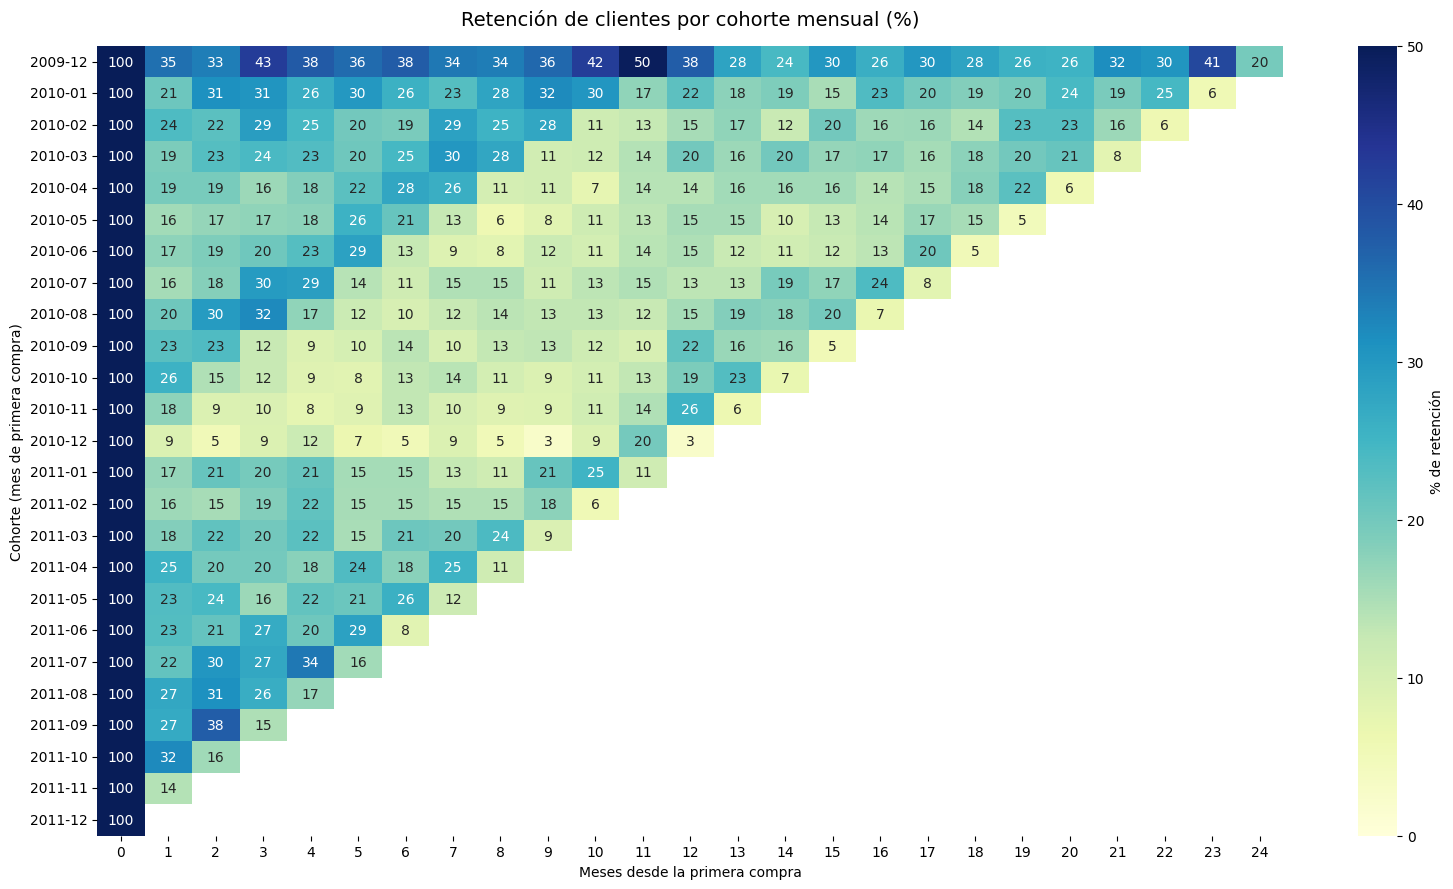

In [83]:
plt.figure(figsize=(16, 9))
sns.heatmap(
    retencion,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu',
    vmin=0, vmax=50,
    cbar_kws={'label': '% de retención'}
)
plt.title('Retención de clientes por cohorte mensual (%)', fontsize=14, pad=15)
plt.xlabel('Meses desde la primera compra')
plt.ylabel('Cohorte (mes de primera compra)')
plt.tight_layout()

# Antes de borrar la memoria
plt.savefig('../reports/heatmap_cohortes.png', dpi=150, bbox_inches='tight')

# Mostramos el gráfico en pantalla
plt.show()

In [84]:
import os
os.makedirs('../reports', exist_ok=True)

In [85]:
from sklearn.preprocessing import StandardScaler

# Variables RFM crudas (no los scores 1-5, sino los valores reales)
X = rfm_scores[['recencia_dias', 'frecuencia', 'monto']].copy()

# Log-transformación para reducir el sesgo (+1 evita log(0))
X_log = np.log1p(X)

# Estandarizar: media 0, desvío 1 para cada variable
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

print(X_scaled.shape)
print(f'Medias: {X_scaled.mean(axis=0).round(3)}')
print(f'Desvíos: {X_scaled.std(axis=0).round(3)}')

(5878, 3)
Medias: [-0.  0. -0.]
Desvíos: [1. 1. 1.]


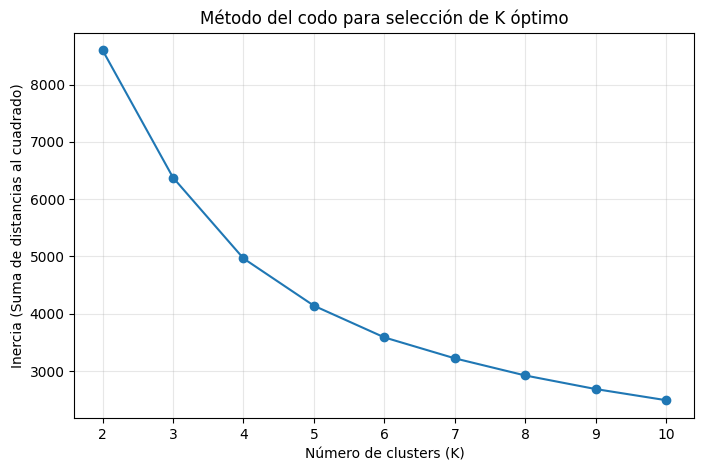

In [86]:
from sklearn.cluster import KMeans

inercias = []
rango_k = range(2, 11)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inercias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(rango_k, inercias, marker='o')

# Textos más profesionales y técnicos
plt.title('Método del codo para selección de K óptimo')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia (Suma de distancias al cuadrado)')
plt.grid(True, alpha=0.3)

# Guardamos la imagen en la carpeta reports, subiendo un nivel desde notebooks/
plt.savefig('../reports/metodo_del_codo.png', bbox_inches='tight', dpi=300)

# Muestra el gráfico en la pantalla del notebook
plt.show()

In [87]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm_scores['cluster'] = kmeans.fit_predict(X_scaled)

# Caracterizar cada cluster: RFM promedio y tamaño
perfil_clusters = rfm_scores.groupby('cluster').agg(
    clientes=('customer_id', 'count'),
    recencia_media=('recencia_dias', 'mean'),
    frecuencia_media=('frecuencia', 'mean'),
    monto_medio=('monto', 'mean'),
    monto_total=('monto', 'sum')
).round(1)

perfil_clusters

,clientes,recencia_media,frecuencia_media,monto_medio,monto_total
cluster,,,,,
0,2056,393.1,1.4,338.6,696246.4
1,1473,210.7,5.4,2113.7,3113509.4
2,1231,27.9,3.0,837.3,1030747.2
3,1118,24.8,20.0,11211.4,12534301.3


In [88]:
comparacion = pd.crosstab(rfm_scores['segmento'], rfm_scores['cluster'])
comparacion

cluster,0,1,2,3
segmento,,,,
Campeones,0,164,161,1019
En riesgo (valiosos),69,612,0,12
Leales,31,650,596,87
Necesitan atención,400,35,72,0
Nuevos / Prometedores,34,0,402,0
Perdidos,1522,12,0,0


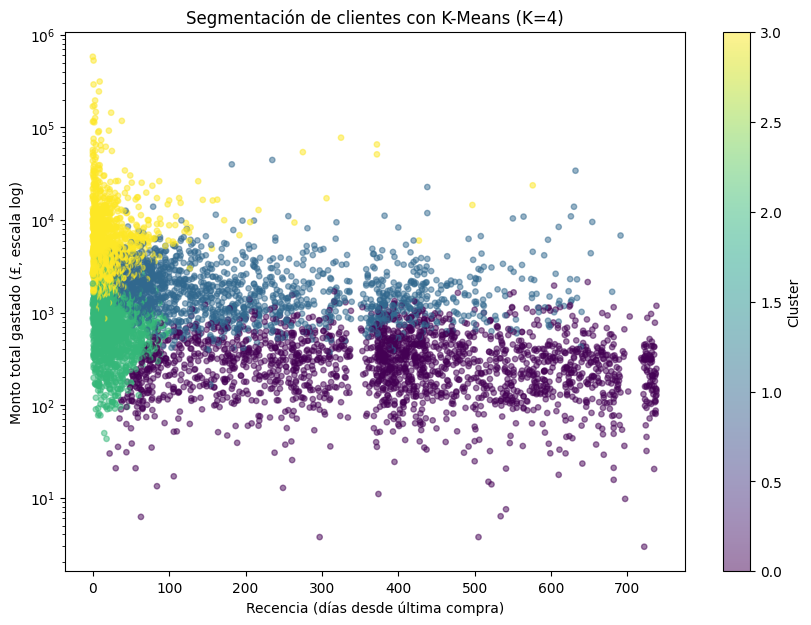

In [89]:
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    rfm_scores['recencia_dias'],
    rfm_scores['monto'],
    c=rfm_scores['cluster'],
    cmap='viridis',
    alpha=0.5,
    s=15
)
ax.set_yscale('log')
ax.set_xlabel('Recencia (días desde última compra)')
ax.set_ylabel('Monto total gastado (£, escala log)')
ax.set_title('Segmentación de clientes con K-Means (K=4)')
plt.colorbar(scatter, label='Cluster')
plt.savefig('../reports/clusters_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()